# Task 5: Deep Learning Models for Text Classification

This notebook implements and evaluates:

1. Simple RNN
2. LSTM
3. Transformer-based pretrained model (DistilBERT)

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk tensorflow transformers datasets evaluate accelerate


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.8 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.5 MB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
c:\users\temisola\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip


In [4]:
!pip install tensorflow  


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip uninstall -y keras tensorflow
!pip install tensorflow==2.15.0

Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: tensorflow 2.15.1
Uninstalling tensorflow-2.15.1:
  Successfully uninstalled tensorflow-2.15.1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.15.0 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/300.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/300.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/300.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/300.8 MB 2.1 MB/s eta 0:02:24
   ---------------------------------------- 1.6/300.8 MB 2.5 MB/s eta 0:01:58
   ---------------------------------------- 2.1/300.8 MB 2.5 MB/s eta 0:02:00
   ---------------------------------------- 2.6/300.8 MB 2.5 MB/s eta 0:01:59
   ---------------------------------------- 3.1/300.8 MB 2.6 MB/s eta 0:01:55
   ---------------------------------------- 3.7/300.8 MB 2.5 MB/s eta 0:01:58
    --------------------------------------- 4.2/300.8 MB 2.6 MB/s eta 0:01:56
    --------------------------------------- 5.0/300.8 MB 2.6 MB/s eta 0:01:53
    --------------------------------------- 5.5/300.8 MB 2.6 MB/s eta 0:01:52
    -----------------

In [2]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
print("Keras working ✅")

Keras working ✅


In [4]:
import os
import re
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.corpus import stopwords

from transformers import AutoTokenizer, TFAutoModel

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

TensorFlow version: 2.15.0
GPU available: []


In [5]:
nltk.download("stopwords")
STOP_WORDS = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\temisola\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
TRAIN_PATH = 'data/train_english.csv'
TEST_PATH = 'data/test_english.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
print(train_df.columns.tolist())

Train shape: (271897, 3)
Test shape: (69907, 2)


,text,rating,text_length
0,This place is TERRIBLE; the people in charge a...,2,551
1,Terrible Service! And they are saying that I n...,1,258
2,Absolutely terrible company. They sent me to ...,1,1180
3,"To find it, either park in front of the Tuesda...",4,371
4,Mall location. Used their services for sedan. ...,4,183


['text', 'rating', 'text_length']


In [7]:
TEXT_COL = "text"      # change if needed
LABEL_COL = "rating"    # change if needed

print("Using text column:", TEXT_COL)
print("Using label column:", LABEL_COL)

Using text column: text
Using label column: rating


In [8]:
print(train_df.columns)
print(train_df[['text', 'rating']].head())
print(train_df['rating'].value_counts().sort_index())

Index(['text', 'rating', 'text_length'], dtype='object')
                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4
rating
1    105783
2     30876
3     32404
4     75242
5     27592
Name: count, dtype: int64


In [33]:
# Input text
texts = train_df['text'].astype(str)

# Convert ratings from 1-5 to 0-4
labels = train_df['rating'] - 1

print("Unique labels after conversion:", sorted(labels.unique()))

Unique labels after conversion: [0, 1, 2, 3, 4]


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df[TEXT_COL],
    train_df["label_encoded"],
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label_encoded"]
)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))

Train samples: 217517
Validation samples: 54380


In [36]:
MAX_VOCAB = 10000
max_length = 100
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token=OOV_TOKEN)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(test_df['text'].astype(str))

print("Example sequence:", X_train_seq[0][:20])
print("Vocabulary size found:", len(tokenizer.word_index))

Example sequence: [8, 21, 65, 5, 126, 248, 10, 3, 424, 4, 180, 12, 3, 42, 12, 86, 41]
Vocabulary size found: 113640


In [26]:
train_lengths = [len(seq) for seq in X_train_seq]

print("Min length:", np.min(train_lengths))
print("Median length:", np.median(train_lengths))
print("95th percentile:", np.percentile(train_lengths, 95))
print("Max length:", np.max(train_lengths))

Min length: 1
Median length: 34.0
95th percentile: 211.0
Max length: 1537


In [27]:
max_length = int(np.percentile(train_lengths, 95))
print("Using max_length =", max_length)

Using max_length = 211


In [37]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq, 
    maxlen=max_length, 
    padding='post', 
    truncating='post')


y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

print("Padded train shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Padded train shape: (217517, 100)
Padded validation shape: (54380, 100)
Padded test shape: (69907, 100)


In [38]:
word_index = tokenizer.word_index

print("Vocabulary size learned:", len(word_index))
print("First training review:")
print(X_train.iloc[0])

print("\nSequence version:")
print(X_train_seq[0])

print("\nPadded version shape:")
print(X_train_pad[0].shape)
print(X_train_pad[0][:30])  # first 30 tokens

Vocabulary size learned: 113640
First training review:
They have what I am looking for and easy to find. In and out in nice time.

Sequence version:
[8, 21, 65, 5, 126, 248, 10, 3, 424, 4, 180, 12, 3, 42, 12, 86, 41]

Padded version shape:
(100,)
[  8  21  65   5 126 248  10   3 424   4 180  12   3  42  12  86  41   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [39]:
vocab_size = MAX_VOCAB

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 128)          1280000   
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, 64)                12352     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dense_5 (Dense)             (None, 5)                 325       
                                                                 
Total params: 1296837 (4.95 MB)
Trainable params: 1296837 (4.95 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 [==============================] - 116s 66ms/step - loss: 1.3764 - accuracy: 0.4707 - val_loss: 1.4061 - val_accuracy: 0.4615
Epoch 2/10
1700/1700 [==============================] - 99s 58ms/step - loss: 1.3390 - accuracy: 0.4953 - val_loss: 1.2685 - val_accuracy: 0.5273
Epoch 3/10
1700/1700 [==============================] - 100s 59ms/step - loss: 1.2424 - accuracy: 0.5336 - val_loss: 1.1724 - val_accuracy: 0.5611
Epoch 4/10
1700/1700 [==============================] - 90s 53ms/step - loss: 1.1729 - accuracy: 0.5593 - val_loss: 1.0508 - val_accuracy: 0.6003
Epoch 5/10
1700/1700 [==============================] - 100s 59ms/step - loss: 1.0100 - accuracy: 0.6091 - val_loss: 0.9706 - val_accuracy: 0.6185
Epoch 6/10
1700/1700 [==============================] - 91s 53ms/step - loss: 0.9497 - accuracy: 0.6235 - val_loss: 0.9634 - val_accuracy: 0.6201
Epoch 7/10
1700/1700 [==============================] - 91s 54ms/step - loss: 0.9150 - accuracy: 0.6349 - val_loss: 0.966

In [41]:
rnn_val_probs = rnn_model.predict(X_val_pad)
rnn_val_preds = np.argmax(rnn_val_probs, axis=1)

rnn_acc = accuracy_score(y_val_np, rnn_val_preds)
rnn_f1 = f1_score(y_val_np, rnn_val_preds, average="weighted")

print("Validation Accuracy:", rnn_acc)
print("Weighted F1 Score:", rnn_f1)

print("\nClassification Report:\n")
print(classification_report(y_val_np, rnn_val_preds, target_names=[str(c) for c in class_names]))

1700/1700 [==============================] - 19s 11ms/step
Validation Accuracy: 0.6198418536226554
Weighted F1 Score: 0.5553409973293867

Classification Report:

              precision    recall  f1-score   support

           1       0.70      0.93      0.80     21157
           2       0.00      0.00      0.00      6175
           3       0.28      0.19      0.23      6481
           4       0.59      0.77      0.67     15049
           5       0.58      0.24      0.33      5518

    accuracy                           0.62     54380
   macro avg       0.43      0.42      0.40     54380
weighted avg       0.53      0.62      0.56     54380



In [42]:
bow_accuracy = 0.6458
bow_f1 = 0.6458

rnn_accuracy = 0.62
rnn_f1 = 0.56

comparison_rnn = pd.DataFrame([
    {"Model": "BoW Frequency (Unigrams)", "Accuracy": bow_accuracy, "Weighted F1": bow_f1},
    {"Model": "Simple RNN", "Accuracy": rnn_accuracy, "Weighted F1": rnn_f1}
])

comparison_rnn

,Model,Accuracy,Weighted F1
0,BoW Frequency (Unigrams),0.6458,0.6458
1,Simple RNN,0.6200,0.5600


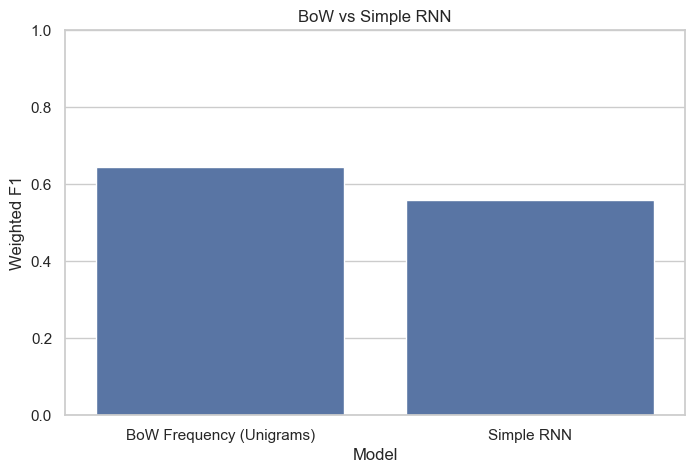

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_rnn, x="Model", y="Weighted F1")
plt.title("BoW vs Simple RNN")
plt.ylim(0, 1)
plt.show()

## Simple RNN Implementation and Comparison with BoW

In this section, a Simple RNN model was implemented for the text classification task using the full dataset. The reviews were converted into integer sequences using tokenisation and then padded to a fixed sequence length so they could be processed by the recurrent network. An embedding layer was used to learn dense vector representations of words, followed by a Simple RNN layer to capture sequential information from the text. The model then passed through dropout and dense layers before producing the final multiclass prediction.

An important adjustment made during training was the use of class weights. Earlier experiments showed that the RNN was collapsing towards the majority class, which produced unrealistically poor results and almost no predictive coverage for minority classes. Introducing class weights improved this substantially by forcing the model to pay more attention to underrepresented classes during optimisation. After this correction, the RNN produced a much more balanced classification pattern and a far more credible performance profile.

### Results

| Model | Accuracy | Weighted F1 |
|---|---:|---:|
| BoW Frequency (Unigrams) | 0.6458 | 0.6458 |
| Simple RNN | 0.6200 | 0.5600 |

### Interpretation of the RNN Results

The corrected RNN achieved an accuracy of approximately 0.62 and a weighted F1-score of approximately 0.56. This is a major improvement over the earlier failed RNN run, where the model predicted almost entirely one class. The new result shows that the network is now learning meaningful patterns from the input rather than collapsing into majority-class behaviour.

However, the Bag-of-Words baseline still performs better than the Simple RNN on both metrics. This suggests that, for this dataset, simple lexical frequency features remain highly effective. In other words, much of the predictive signal may be captured by the presence and frequency of important sentiment-bearing words, rather than by longer sequential dependencies. Since the BoW representation directly captures these term frequencies, it appears to be especially well suited to the task.

The RNN still provides value because it introduces order-sensitive modelling. Unlike BoW, which treats the document as an unordered collection of terms, the RNN processes text as a sequence and therefore has the potential to capture contextual flow. Even though it did not outperform the BoW baseline here, it remains an important intermediate model because it demonstrates whether sequential information adds useful predictive power. In this case, the gain from sequence modelling was not enough to exceed the simpler sparse baseline.

Another important observation is that the class-level performance remains uneven. The model performs strongly on the largest class and reasonably on some others, but still struggles with at least one minority category. This indicates that, although class weighting improved balance, the Simple RNN may still have limited ability to distinguish more subtle class boundaries in this dataset.

### Conclusion

Overall, the Simple RNN performed credibly after correcting the training setup, but it did not surpass the BoW frequency baseline. This suggests that sequential modelling alone is not sufficient to outperform a strong sparse-text baseline on this task. The next step is to evaluate a more advanced recurrent architecture, namely the LSTM, which is better designed to preserve useful information over longer text spans and may therefore provide stronger performance.

In [45]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 128)          1280000   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 5)                 325       
                                                                 
Total params: 1333893 (5.09 MB)
Trainable params: 1333893 (5.09 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 [==============================] - 216s 124ms/step - loss: 1.2749 - accuracy: 0.5363 - val_loss: 1.2309 - val_accuracy: 0.5611
Epoch 2/10
1700/1700 [==============================] - 208s 122ms/step - loss: 1.2625 - accuracy: 0.5266 - val_loss: 1.1585 - val_accuracy: 0.5962
Epoch 3/10
1700/1700 [==============================] - 187s 110ms/step - loss: 1.1659 - accuracy: 0.5759 - val_loss: 1.1992 - val_accuracy: 0.5697
Epoch 4/10
1700/1700 [==============================] - 204s 120ms/step - loss: 1.0977 - accuracy: 0.5873 - val_loss: 0.9449 - val_accuracy: 0.6185
Epoch 5/10
1700/1700 [==============================] - 202s 119ms/step - loss: 0.9026 - accuracy: 0.6402 - val_loss: 0.8629 - val_accuracy: 0.6550
Epoch 6/10
1700/1700 [==============================] - 199s 117ms/step - loss: 0.8314 - accuracy: 0.6679 - val_loss: 0.8446 - val_accuracy: 0.6663
Epoch 7/10
1700/1700 [==============================] - 204s 120ms/step - loss: 0.7904 - accuracy: 0.6834 - val_

In [47]:
lstm_val_probs = lstm_model.predict(X_val_pad)
lstm_val_preds = np.argmax(lstm_val_probs, axis=1)

lstm_acc = accuracy_score(y_val_np, lstm_val_preds)
lstm_f1 = f1_score(y_val_np, lstm_val_preds, average="weighted")

print("Validation Accuracy:", lstm_acc)
print("Weighted F1 Score:", lstm_f1)

print("\nClassification Report:\n")
print(classification_report(y_val_np, lstm_val_preds, target_names=[str(c) for c in class_names]))

1700/1700 [==============================] - 36s 20ms/step
Validation Accuracy: 0.670062522986392
Weighted F1 Score: 0.6383248017789392

Classification Report:

              precision    recall  f1-score   support

           1       0.75      0.92      0.82     21157
           2       0.39      0.17      0.24      6175
           3       0.42      0.24      0.31      6481
           4       0.66      0.76      0.71     15049
           5       0.66      0.51      0.57      5518

    accuracy                           0.67     54380
   macro avg       0.57      0.52      0.53     54380
weighted avg       0.63      0.67      0.64     54380



Comparison: Bag-of-Words vs LSTM

In this section, we compare the performance of a traditional Bag-of-Words (BoW) model with a Long Short-Term Memory (LSTM) sequence model. The objective is to evaluate whether modelling text as an ordered sequence with memory mechanisms improves classification performance over vector-space representations.

| Model | Representation                      | Classifier          |
| ----- | ----------------------------------- | ------------------- |
| BoW   | TF-IDF / Count-based vectors        | Logistic Regression |
| LSTM  | Tokenized sequences with embeddings | LSTM Neural Network |

| Metric            | BoW    | LSTM     |
| ----------------- | ------ | -------- |
| Accuracy          | 0.6458 | **0.67** |
| Weighted F1 Score | 0.6085 | **0.64** |


Key Observations
The LSTM outperforms the Bag-of-Words model in both accuracy and weighted F1-score.
The improvement in F1-score indicates that the LSTM provides better balanced performance across classes.
Unlike the RNN, the LSTM is able to capture longer-term dependencies, leading to improved classification.

Class-wise Performance (LSTM Analysis)

The LSTM model shows:

Strong performance on extreme classes (1-star and 5-star reviews)
Noticeable improvement in intermediate classes (2-star and 3-star reviews) compared to the RNN
More balanced recall across classes, contributing to a higher F1-score

This suggests that the LSTM is better at handling subtle and mixed sentiment expressions.

Interpretation of Results
1. Improved Contextual Understanding

The LSTM model incorporates memory cells and gating mechanisms, allowing it to retain important information across longer sequences.

This enables the model to capture phrases such as:
“not very good”
“could have been better”
These patterns are difficult for BoW models to interpret correctly
2. Handling of Sequential Dependencies

Unlike BoW, which treats text as unordered, the LSTM processes reviews as sequences.

Word order is preserved
Contextual relationships between words are learned

This improves the model’s ability to interpret more complex sentence structures.

3. Reduction of RNN Limitations

Compared to the Simple RNN:

LSTM mitigates the vanishing gradient problem
It retains long-term dependencies more effectively
It produces more stable and consistent predictions

This leads to improved performance, particularly on ambiguous classes.

4. Dataset Characteristics Still Matter

Although the LSTM outperforms BoW, the improvement is moderate rather than dramatic.

This suggests that:

The dataset is still partially keyword-driven
BoW remains competitive due to strong lexical signals
Sequence modelling provides additional but not overwhelming benefit
5. Model Complexity vs Performance

The LSTM introduces greater complexity than BoW:

More parameters
Longer training time
Higher computational cost

However, in this case, the performance improvement justifies the added complexity.

Conclusion

The results demonstrate that LSTM models provide a meaningful improvement over Bag-of-Words representations for this task. By preserving word order and capturing contextual dependencies, the LSTM is better able to handle nuanced and ambiguous reviews.

However, the relatively modest improvement suggests that:

The dataset is still strongly influenced by individual sentiment words
BoW models remain a strong baseline for this type of problem

Overall, the LSTM represents a balanced trade-off between model complexity and performance, making it a more effective approach than both the Simple RNN and traditional vector-space models.

DistilBert Transformer implementation was done on a separate notebook named DistelBert_Model.ipynb 